In [25]:
import os
import shutil
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib 
import matplotlib.pyplot as plt
import numpy as np
#matplotlib.use("agg")

In [26]:
# set device to 'cuda' if CUDA is available, 'mps' if MPS is available,
# or 'cpu' otherwise for model training and testing
DEVICE = ( "mps" if torch.mps.is_available() else "cpu" )
print(f"Using device: {DEVICE}")

Using device: mps


In [27]:
# define model hyperparameters
LR = 0.001
PATIENCE = 15
IMAGE_SIZE = 32
CHANNELS = 1
BATCH_SIZE = 64
EMBEDDING_DIM = 2
EPOCHS = 100
SHAPE_BEFORE_FLATTENING = (128, IMAGE_SIZE // 8, IMAGE_SIZE // 8)

class Config:
    LR = LR
    PATIENCE = PATIENCE
    IMAGE_SIZE = IMAGE_SIZE
    CHANNELS = CHANNELS
    BATCH_SIZE = BATCH_SIZE
    EMBEDDING_DIM = EMBEDDING_DIM
    EPOCHS = EPOCHS
    SHAPE_BEFORE_FLATTENING = SHAPE_BEFORE_FLATTENING

config = Config()

# create output directory
output_dir = "output"
os.makedirs("output", exist_ok=True)

In [28]:
# create output directory (clear old contents if they exist)
output_dir = "output"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

In [29]:
# create the training_progress directory inside the output directory
training_progress_dir = os.path.join(output_dir, "training_progress")
os.makedirs(training_progress_dir, exist_ok=True)
# create the model_weights directory inside the output directory
# for storing variational autoencoder weights
model_weights_dir = os.path.join(output_dir, "model_weights")
os.makedirs(model_weights_dir, exist_ok=True)
# define model_weights, reconstruction & real before training images paths
MODEL_WEIGHTS_PATH = os.path.join(model_weights_dir, "best_vae.pt")

In [30]:
FILE_RECON_BEFORE_TRAINING = os.path.join(
    output_dir, "reconstruct_before_train.png"
)
FILE_REAL_BEFORE_TRAINING = os.path.join(
    output_dir, "real_test_images_before_train.png"
)
# define reconstruction & real after training images paths
FILE_RECON_AFTER_TRAINING = os.path.join(
    output_dir, "reconstruct_after_train.png"
)
FILE_REAL_AFTER_TRAINING = os.path.join(
    output_dir, "real_test_images_after_train.png"
)
# define latent space and image grid embeddings plot paths
LATENT_SPACE_PLOT = os.path.join(output_dir, "embedding_visualize.png")
IMAGE_GRID_EMBEDDINGS_PLOT = os.path.join(
    output_dir, "image_grid_on_embeddings.png"
)
# define linearly and normally sampled latent space reconstructions plot paths
LINEARLY_SAMPLED_RECONSTRUCTIONS_PLOT = os.path.join(
    output_dir, "linearly_sampled_reconstructions.png"
)
NORMALLY_SAMPLED_RECONSTRUCTIONS_PLOT = os.path.join(
    output_dir, "normally_sampled_reconstructions.png"
)
# define class labels dictionary
CLASS_LABELS = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

## Data Preparation & Inspection
We load the Fashion-MNIST dataset to check its dimensions, channels, and pixel distribution before defining the VAE architecture.

In [31]:
# Load the FashionMNIST training set using transforms.ToTensor() only
raw_train_data = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=transforms.ToTensor()
)

# Extract a single image tensor and its label
img, label = raw_train_data[0]

# Print critical information
print(f"1. Image Shape and Number of Channels: {list(img.shape)}")
print(f"2. Max pixel value: {img.max().item()}, Min pixel value: {img.min().item()}")
print(f"3. Total number of training samples: {len(raw_train_data)}")
print(f"4. Class names: {raw_train_data.classes}")

1. Image Shape and Number of Channels: [1, 28, 28]
2. Max pixel value: 1.0, Min pixel value: 0.0
3. Total number of training samples: 60000
4. Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [32]:
# define the transformation to be applied to the data
transform = transforms.Compose([
    transforms.Pad(padding=2),
    transforms.ToTensor()
])
# load the FashionMNIST training data and create a dataloader
trainset = datasets.FashionMNIST(
    "data", train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=config.BATCH_SIZE, shuffle=True
)
# load the FashionMNIST test data and create a dataloader
testset = datasets.FashionMNIST(
    "data", train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(
    testset, batch_size=config.BATCH_SIZE, shuffle=True
)

# Extract one batch from train_loader and print the new batch shape
batch_imgs, batch_labels = next(iter(train_loader))
print(f"New batch shape: {list(batch_imgs.shape)}")

New batch shape: [64, 1, 32, 32]


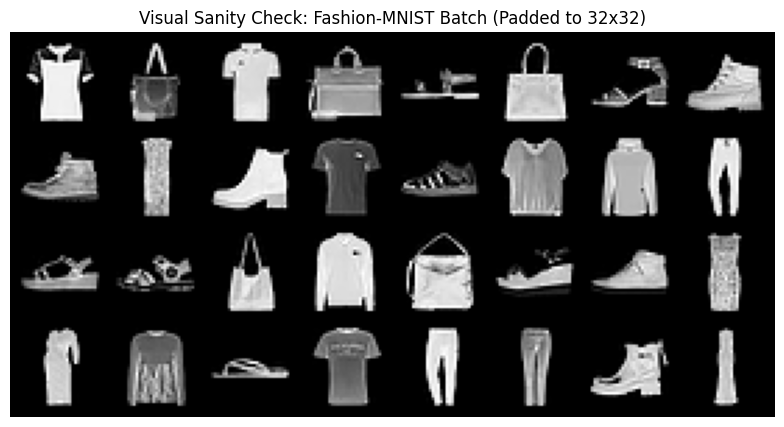

In [33]:
#Visualize a Data Batch
# Get a single batch of images from the train_loader
images, labels = next(iter(train_loader))

# Visualize a grid of 32 images
grid_img = torchvision.utils.make_grid(images[:32], nrow=8)
plt.figure(figsize=(10, 5))
plt.title("Visual Sanity Check: Fashion-MNIST Batch (Padded to 32x32)")
plt.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)))
plt.axis("off")
plt.show()

## Train


In [34]:
import vae_model_architecture
import utils

In [35]:
# Initialize encoder, decoder, and VAE
encoder = vae_model_architecture.Encoder(config.IMAGE_SIZE, config.EMBEDDING_DIM)
decoder = vae_model_architecture.Decoder(config.EMBEDDING_DIM, config.SHAPE_BEFORE_FLATTENING)
model = vae_model_architecture.VAE(encoder, decoder).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=config.LR)

In [36]:
# Visualize reconstructions before training
model.eval()
with torch.no_grad():
    # Get a batch of test images
    test_batch, _ = next(iter(test_loader))
    test_batch = test_batch.to(DEVICE)
    mu, logvar, recon = model(test_batch)
    
    # Save real before training images
    grid_real = torchvision.utils.make_grid(test_batch[:16], nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(grid_real.cpu().numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Real Test Images (Before Train)")
    plt.savefig(FILE_REAL_BEFORE_TRAINING)
    plt.close()
    
    # Save reconstruction before training images
    grid_recon = torchvision.utils.make_grid(recon[:16], nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(grid_recon.cpu().numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Reconstructed Images (Before Train)")
    plt.savefig(FILE_RECON_BEFORE_TRAINING)
    plt.close()

print("Initial model check completed. Real and reconstructed images before training have been saved.")

Initial model check completed. Real and reconstructed images before training have been saved.


In [37]:
# Training loop with validation and early stopping
best_loss = float("inf")
patience_counter = 0

# Lists to track loss progress
train_losses = []
train_recon_losses = []
train_kld_losses = []

test_losses = []
test_recon_losses = []
test_kld_losses = []

for epoch in range(config.EPOCHS):
    # 1. Training Phase
    model.train()
    epoch_train_loss = 0.0
    epoch_train_recon = 0.0
    epoch_train_kld = 0.0
    
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(DEVICE)
        optimizer.zero_grad()
        
        # Forward pass
        mu, logvar, recon_x = model(batch_x)
        
        # Calculate individual losses from utils
        recon_loss = utils.reconstruction_loss(recon_x, batch_x)
        kld_loss = utils.vae_gaussian_kl_loss(mu, logvar)
        
        # Combined weighted loss (500 * recon + kld)
        loss = 500 * recon_loss + kld_loss
        
        # Backward pass & optimize
        loss.backward()
        optimizer.step()
        
        # Accumulate losses weighted by batch size
        epoch_train_loss += loss.item() * batch_x.size(0)
        epoch_train_recon += recon_loss.item() * batch_x.size(0)
        epoch_train_kld += kld_loss.item() * batch_x.size(0)
        
    # Average training losses over the epoch
    epoch_train_loss /= len(train_loader.dataset)
    epoch_train_recon /= len(train_loader.dataset)
    epoch_train_kld /= len(train_loader.dataset)
    
    train_losses.append(epoch_train_loss)
    train_recon_losses.append(epoch_train_recon)
    train_kld_losses.append(epoch_train_kld)
    
    # 2. Validation/Testing Phase
    model.eval()
    epoch_test_loss = 0.0
    epoch_test_recon = 0.0
    epoch_test_kld = 0.0
    
    with torch.no_grad():
        for batch_x, _ in test_loader:
            batch_x = batch_x.to(DEVICE)
            
            # Forward pass
            mu, logvar, recon_x = model(batch_x)
            
            # Calculate individual losses
            recon_loss = utils.reconstruction_loss(recon_x, batch_x)
            kld_loss = utils.vae_gaussian_kl_loss(mu, logvar)
            loss = 500 * recon_loss + kld_loss
            
            # Accumulate validation losses
            epoch_test_loss += loss.item() * batch_x.size(0)
            epoch_test_recon += recon_loss.item() * batch_x.size(0)
            epoch_test_kld += kld_loss.item() * batch_x.size(0)
            
    # Average validation losses over the epoch
    epoch_test_loss /= len(test_loader.dataset)
    epoch_test_recon /= len(test_loader.dataset)
    epoch_test_kld /= len(test_loader.dataset)
    
    test_losses.append(epoch_test_loss)
    test_recon_losses.append(epoch_test_recon)
    test_kld_losses.append(epoch_test_kld)
    
    # Print separate loss logs for easy monitoring
    print(
        f"Epoch {epoch+1:02d}/{config.EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f} (Recon: {epoch_train_recon:.4f}, KL: {epoch_train_kld:.4f}) | "
        f"Test Loss: {epoch_test_loss:.4f} (Recon: {epoch_test_recon:.4f}, KL: {epoch_test_kld:.4f})"
    )
    
    # Save training progress images periodically (first epoch and every 10 epochs)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        with torch.no_grad():
            sample_recon = recon_x[:16]
            grid = torchvision.utils.make_grid(sample_recon, nrow=4)
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(f"Reconstructions at Epoch {epoch+1}")
            plt.savefig(os.path.join(training_progress_dir, f"epoch_{epoch+1}.png"))
            plt.close()

    # Check for early stopping and save best model
    if epoch_test_loss < best_loss:
        best_loss = epoch_test_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_WEIGHTS_PATH)
        print("--> Saved best model weights!")
    else:
        patience_counter += 1
        if patience_counter >= config.PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

Epoch 01/100 | Train Loss: 147.9979 (Recon: 0.2863, KL: 4.8720) | Test Loss: 136.8794 (Recon: 0.2637, KL: 5.0425)
--> Saved best model weights!
Epoch 02/100 | Train Loss: 135.2592 (Recon: 0.2607, KL: 4.9069) | Test Loss: 135.0991 (Recon: 0.2598, KL: 5.2005)
--> Saved best model weights!
Epoch 03/100 | Train Loss: 133.9009 (Recon: 0.2578, KL: 5.0053) | Test Loss: 134.0257 (Recon: 0.2583, KL: 4.8952)
--> Saved best model weights!
Epoch 04/100 | Train Loss: 133.1317 (Recon: 0.2561, KL: 5.0799) | Test Loss: 133.4853 (Recon: 0.2570, KL: 4.9889)
--> Saved best model weights!
Epoch 05/100 | Train Loss: 132.6840 (Recon: 0.2551, KL: 5.1354) | Test Loss: 133.3728 (Recon: 0.2564, KL: 5.1480)
--> Saved best model weights!
Epoch 06/100 | Train Loss: 132.2524 (Recon: 0.2541, KL: 5.1882) | Test Loss: 132.8265 (Recon: 0.2549, KL: 5.3684)
--> Saved best model weights!
Epoch 07/100 | Train Loss: 131.9901 (Recon: 0.2535, KL: 5.2301) | Test Loss: 132.6350 (Recon: 0.2545, KL: 5.3791)
--> Saved best model w

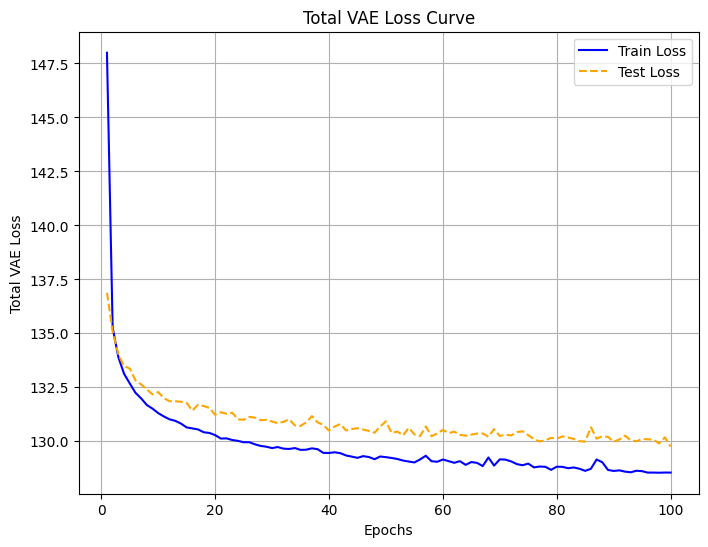

In [47]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_losses, label='Train Loss', color='blue')
plt.plot(epochs_range, test_losses, label='Test Loss', color='orange', linestyle='--')

plt.xlabel('Epochs')
plt.ylabel('Total VAE Loss')
plt.title('Total VAE Loss Curve')
plt.legend()
plt.grid(True)

# Lưu ảnh riêng
plt.savefig(os.path.join(output_dir, "total_loss_curve.png"), bbox_inches='tight')
plt.show()

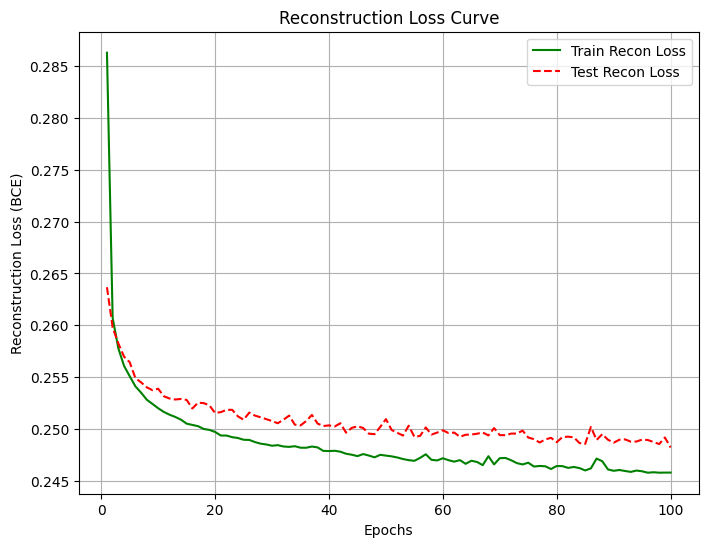

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_recon_losses, label='Train Recon Loss', color='green')
plt.plot(epochs_range, test_recon_losses, label='Test Recon Loss', color='red', linestyle='--')

plt.xlabel('Epochs')
plt.ylabel('Reconstruction Loss (BCE)')
plt.title('Reconstruction Loss Curve')
plt.legend()
plt.grid(True)


plt.savefig(os.path.join(output_dir, "recon_loss_curve.png"), bbox_inches='tight')
plt.show()

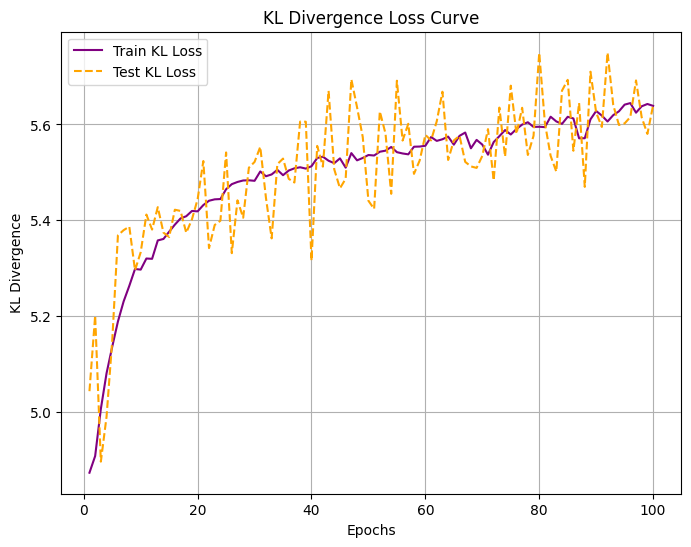

In [46]:
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_kld_losses, label='Train KL Loss', color='purple') # Đổi sang màu tím cho dễ phân biệt
plt.plot(epochs_range, test_kld_losses, label='Test KL Loss', color='orange', linestyle='--')

plt.xlabel('Epochs')
plt.ylabel('KL Divergence')
plt.title('KL Divergence Loss Curve')
plt.legend()
plt.grid(True)


plt.savefig(os.path.join(output_dir, "kld_loss_curve.png"), bbox_inches='tight')
plt.show()

## Post-Training Evaluation and Visualizations
We load the best VAE model weights and evaluate the performance on the test set. Then, we visualize the reconstructed images, latent space distribution, and generate new fashion items by sampling the latent space.

In [39]:
# Load the best VAE model weights
model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH))
model.eval()

VAE(
  (encoder): Encoder(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc_mean): Linear(in_features=2048, out_features=2, bias=True)
    (fc_log_var): Linear(in_features=2048, out_features=2, bias=True)
    (sampling): Sampling()
  )
  (decoder): Decoder(
    (fc): Linear(in_features=2, out_features=2048, bias=True)
    (deconv1): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (deconv2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (deconv3): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
)

In [40]:
# 1. Save reconstruction & real after training images
with torch.no_grad():
    test_batch, _ = next(iter(test_loader))
    test_batch = test_batch.to(DEVICE)
    mu, logvar, recon = model(test_batch)
    
    # Save real test images after training
    grid_real = torchvision.utils.make_grid(test_batch[:16], nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(grid_real.cpu().numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Real Test Images (After Train)")
    plt.savefig(FILE_REAL_AFTER_TRAINING)
    plt.close()
    
    # Save reconstructed test images after training
    grid_recon = torchvision.utils.make_grid(recon[:16], nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(grid_recon.cpu().numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Reconstructed Images (After Train)")
    plt.savefig(FILE_RECON_AFTER_TRAINING)
    plt.close()


In [41]:
# 2. Latent Space Plot (embedding visualization)
all_mus = []
all_labels = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(DEVICE)
        mu, _, _ = model.encoder(batch_x)
        all_mus.append(mu.cpu())
        all_labels.append(batch_y)
        if len(all_mus) * config.BATCH_SIZE >= 5000:
            break
all_mus = torch.cat(all_mus, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_mus[:, 0], all_mus[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10), label="Class Label")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.title("Latent Space (2D Embeddings of Test Set)")
plt.savefig(LATENT_SPACE_PLOT)
plt.close()


In [42]:
# 3. Linearly Sampled Reconstructions (spanning the 2D grid)
n = 15  # 15x15 grid of images
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

generated_imgs = []
with torch.no_grad():
    for y in grid_y[::-1]:  # Top to bottom
        for x in grid_x:    # Left to right
            z = torch.tensor([[x, y]], dtype=torch.float32).to(DEVICE)
            recon = model.decoder(z)
            generated_imgs.append(recon.cpu())
            
generated_imgs = torch.cat(generated_imgs, dim=0)
grid_recon = torchvision.utils.make_grid(generated_imgs, nrow=n)
plt.figure(figsize=(10, 10))
plt.imshow(np.transpose(grid_recon.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Linearly Sampled Latent Space Grid")
plt.savefig(LINEARLY_SAMPLED_RECONSTRUCTIONS_PLOT)
plt.savefig(IMAGE_GRID_EMBEDDINGS_PLOT)
plt.close()

# 4. Normally Sampled Reconstructions
with torch.no_grad():
    z = torch.randn(64, config.EMBEDDING_DIM).to(DEVICE)
    recon = model.decoder(z)
    
grid_normal = torchvision.utils.make_grid(recon, nrow=8)
plt.figure(figsize=(8, 8))
plt.imshow(np.transpose(grid_normal.cpu().numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Normally Sampled Latent Space Reconstructions")
plt.savefig(NORMALLY_SAMPLED_RECONSTRUCTIONS_PLOT)
plt.close()

print("Evaluation and all visualizations completed successfully!")

Evaluation and all visualizations completed successfully!
